### Cambio en las abundancias considerando únicamente acreción

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...


/home/javibiss/myenv/lib/python3.14/site-packages/PBHBeta/functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


Vectorizando integraciones de acreción...
Calculando DM con Acreción (Campo Escalar)...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionsaccret.py:212: RuntimeWarning: invalid value encountered in scalar power
  Om_0   = beta0 * b * (1. - time / Delta_t)**(1./3)


Graficando restricción de DM...


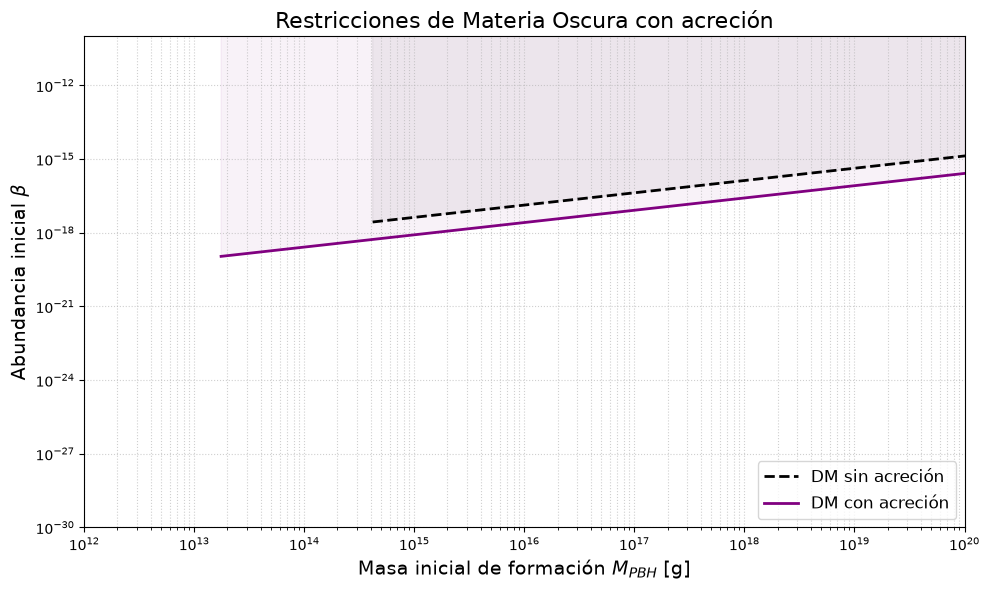

In [2]:
def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Radiación después del Reheating
    N_fin = 55
    a_star = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = [] # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = [] # Limpiamos de nuevo
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción (Campo Escalar)...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # PBHBeta usa valores "dummy" enormes (como 1e-5) cuando el PBH no es DM.
    # Filtramos cualquier valor mayor a 1e-10 convirtiéndolo en 'nan' para que desaparezca.
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin acreción", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="DM con acreción", color="purple", lw=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial $\beta$', fontsize=14)
    plt.title('Restricciones de Materia Oscura con acreción', fontsize=16)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.1)
    plt.fill_between(M_tot, betas_new_clean, 1, color='purple', alpha=0.05)
    
    # Rango donde habitan los PBH de Materia Oscura
    plt.ylim(1e-30, 1e-10)
    plt.xlim(1e12, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

In [ ]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.9
    N_efolds_list = [53, 54, 55, 55.1]
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, N_fin in enumerate(N_efolds_list):
        print(f"   -> Procesando N_fin = {N_fin}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_new.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($N_{{efolds}} = {N_fin}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según la duración del Reheating ($a_*={a_star}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()

1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando N_fin = 53...


1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...


/home/javibiss/myenv/lib/python3.14/site-packages/PBHBeta/functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionsaccret.py:212: RuntimeWarning: invalid value encountered in scalar power
  Om_0   = beta0 * b * (1. - time / Delta_t)**(1./3)


5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


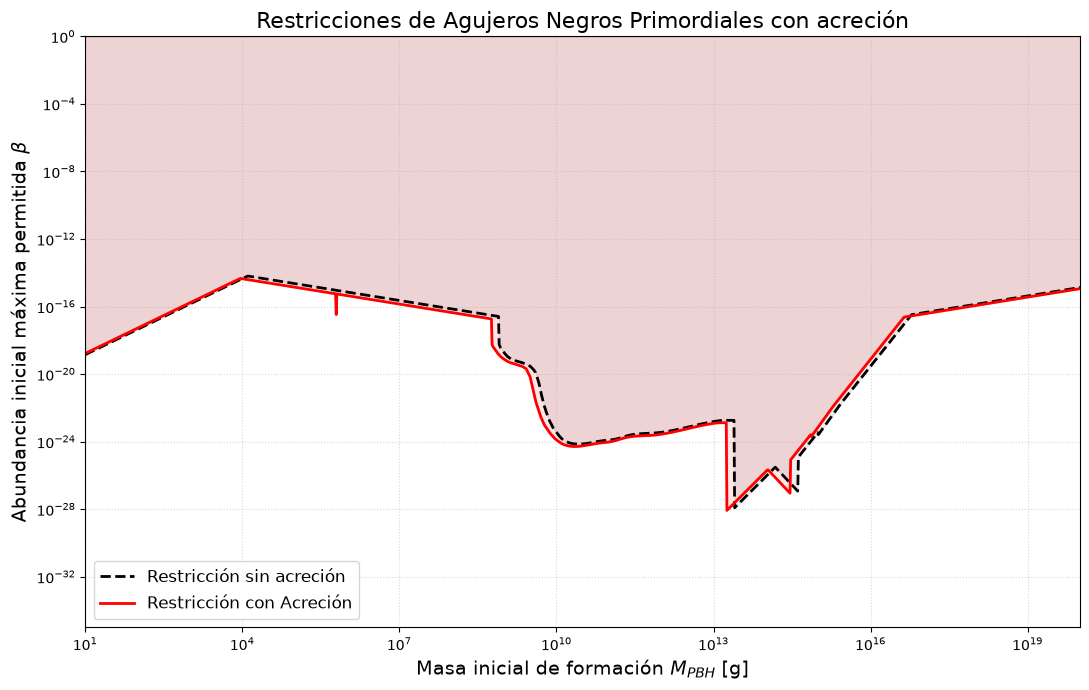

In [3]:

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    
    # Época de Reheating dominada por materia
    omega = 1.0/3.0 
    N_fin = 55
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_new.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(r'Restricciones de Agujeros Negros Primordiales con acreción($a={a_star},N = {N_fin}$)', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()


1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando a_{*} = 0.0...
   -> Procesando a_{*} = 0.7...
   -> Procesando a_{*} = 0.9...
   -> Procesando a_{*} = 0.99...
4/4 - Renderizando gráfica final...


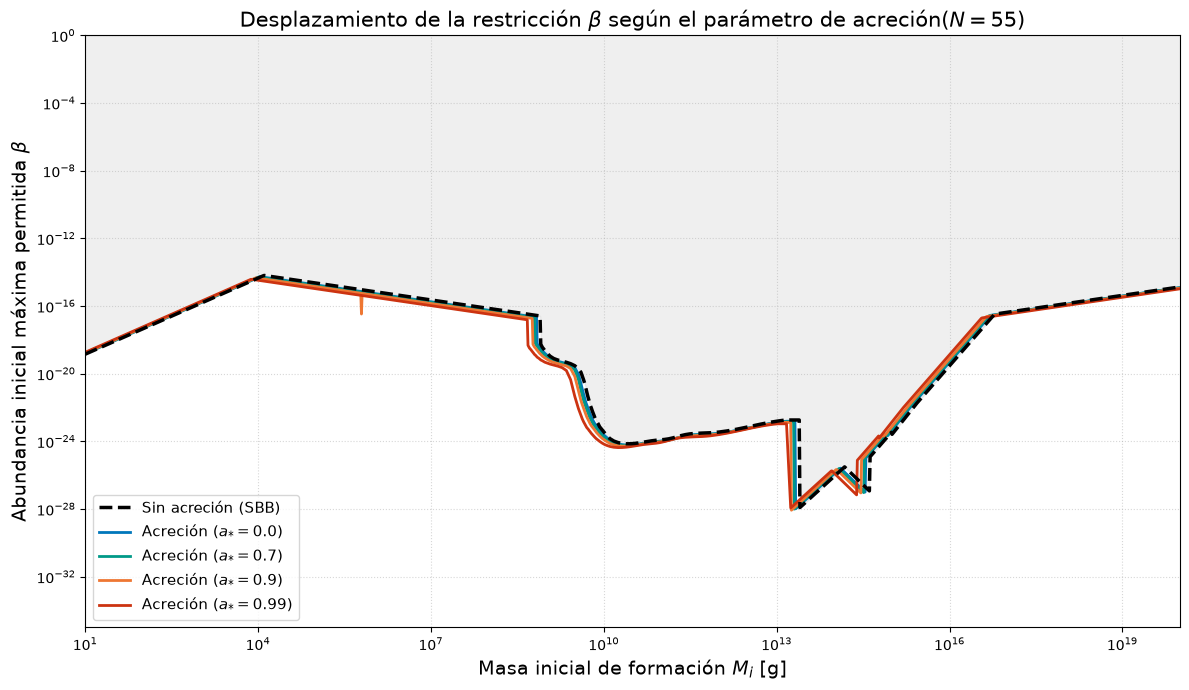

In [4]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star_list =[0.0, 0.7, 0.9, 0.99] 
    N_fin = 55
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, a_star in enumerate(a_star_list):
        print(f"   -> Procesando a_{{*}} = {a_star}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, float(a_star))
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_new.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($a_{{*}} = {a_star}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según el parámetro de acreción($N={N_fin}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


/tmp/ipykernel_21057/462548711.py:119: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


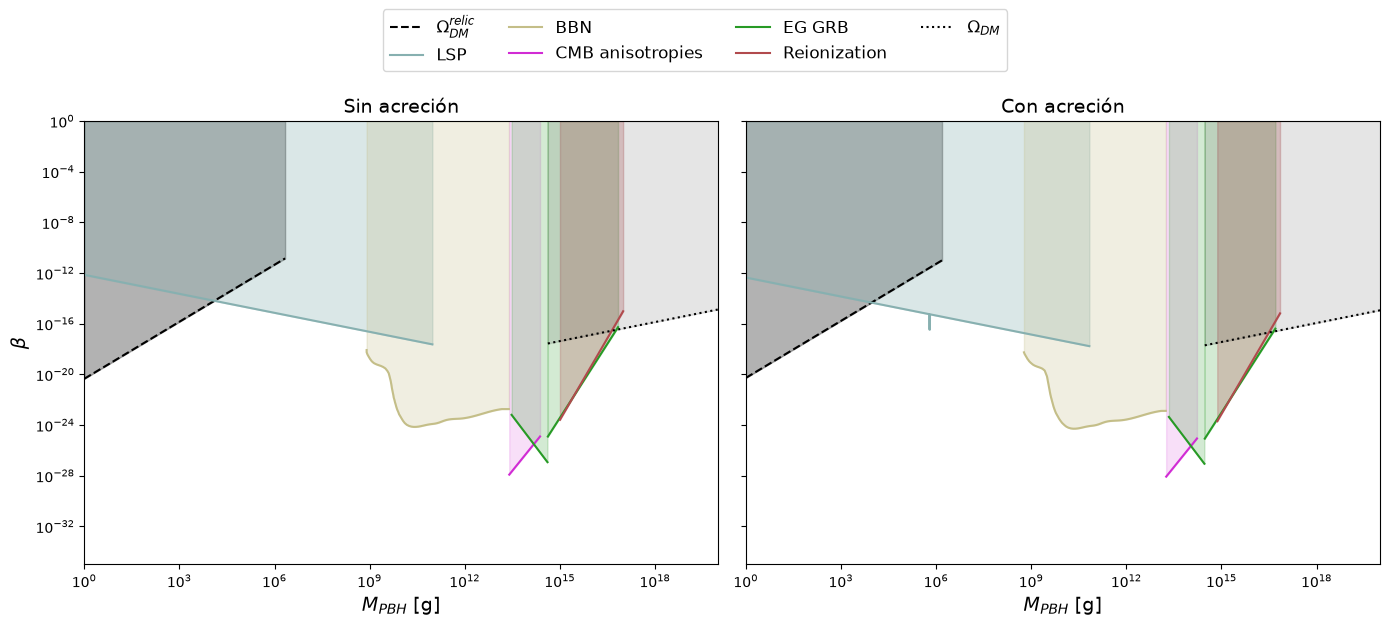

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Reheating dominado por materia
    N = 55
    a = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N, a)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title("Con acreción", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

### Cambio en las abundancias considerando acreción y evaporación durante reheating

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionscompleto as fn_comp
from PBHBeta import constants
from PBHBeta import constraints


Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...
Vectorizando integraciones de acreción...
Calculando DM con Acreción y Evaporación...
Graficando restricción de DM...


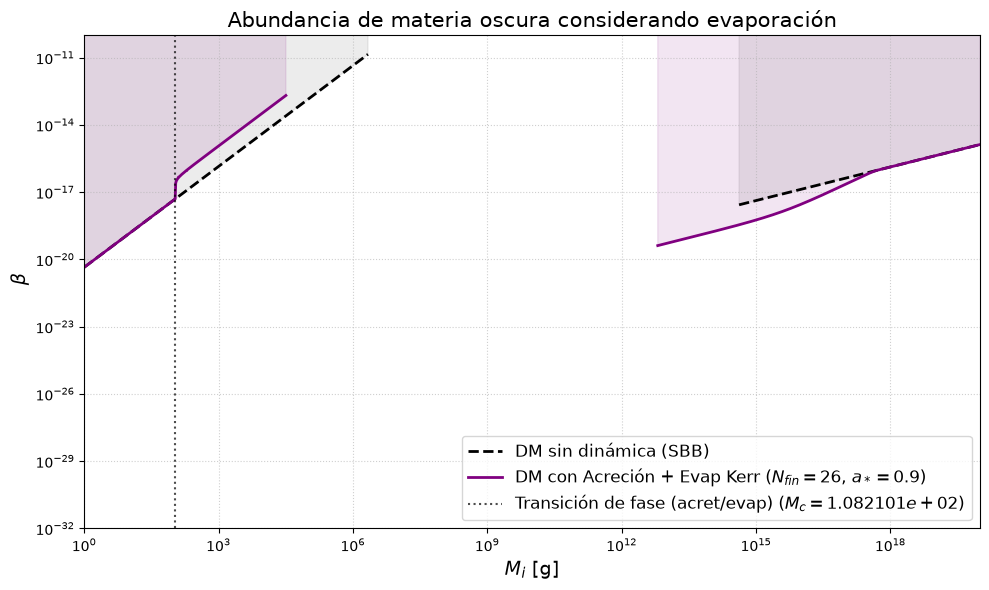

In [5]:
def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0 / 3.0  # Era de radiación (post-reheating)
    
    # Parámetros del modelo
    N_fin = 26.0
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = []  # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN Y EVAPORACIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = []  # Limpiamos la memoria de nuevo
    
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    # Precalculamos la acreción enviando N_fin y a_star
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), float(a_star))
    M_c = fn_comp.calcular_masa_critica_transicion(float(a_star))
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción y Evaporación...")
    # CORRECCIÓN: Ya no enviamos a_star_f_tot, el modelo analítico no lo necesita
    fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # Filtramos valores dummy (> 1e-10) a NaN para graficar únicamente regiones físicas
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin dinámica (SBB)", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label=f"DM con Acreción + Evap Kerr ($N_{{fin}}={int(N_fin)}$, $a_*={a_star}$)", color="purple", lw=2)
    plt.axvline(M_c, color = 'black', linestyle=':', alpha=0.7, label = f'Transición de fase (acret/evap) $(M_c = {M_c:2e})$')
    # Mascaras seguras para el sombreado evitando NaNs
    mask_orig = ~np.isnan(betas_orig_clean)
    mask_new = ~np.isnan(betas_new_clean)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, where=mask_new, color='purple', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$M_i$ [g]', fontsize=14)
    plt.ylabel(r' $\beta$', fontsize=14)
    plt.title('Abundancia de materia oscura considerando evaporación', fontsize=15)
  
    plt.ylim(1e-32, 1e-10)
    plt.xlim(1.0, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

In [10]:
a_star = 0.9
f_acc_base = 1e-18
M_pl_GeV = 1.22089e19
M_pl_g = 2.17645e-5
H_end_GeV = 4.44e13 
H_end_pl = H_end_GeV/M_pl_GeV
n = 100.0

ins = (16*(1-a_star**2.0)**2.0)/(9*f_acc_base*(1+jnp.sqrt(1-a_star**2.0))*n*H_end_pl)
M_c = ins**(1.0/3.0) * M_pl_g

print(f"La masa crítica para la transición es fase es {M_c:2e} g")

La masa crítica para la transición es fase es 1.082101e+02 g


1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...
3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscompleto.py:391: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)
/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscompleto.py:609: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)


5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


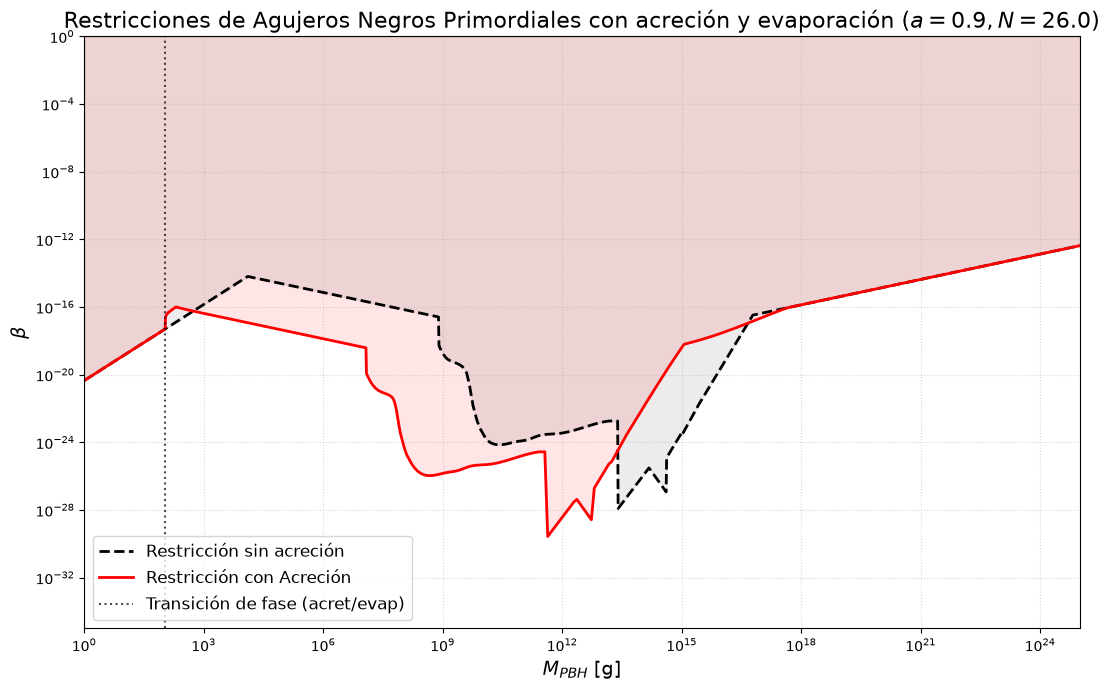

In [6]:

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e25)
    
    omega = 1.0/3.0 #Época dominada por radiación
    N_fin = 26.00
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    M_c = fn_comp.calcular_masa_critica_transicion(float(a_star))
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_comp.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    diff_log_Mf = np.abs(np.diff(np.log10(M_f_tot), prepend=np.log10(M_f_tot[0])))
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.axvline(M_c, color = 'black', linestyle=':', alpha=0.7, label = 'Transición de fase (acret/evap)')
    plt.xlabel(r'$M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'$\beta$', fontsize=14)
    plt.title(f'Restricciones de Agujeros Negros Primordiales con acreción y evaporación ($a={a_star},N = {N_fin}$)', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1.0, 1e25) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()

1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción y masas críticas para cada spin...
   -> Procesando a_* = 0.0...
   -> Procesando a_* = 0.7...
   -> Procesando a_* = 0.9...
   -> Procesando a_* = 0.99...
4/4 - Renderizando gráfica final...


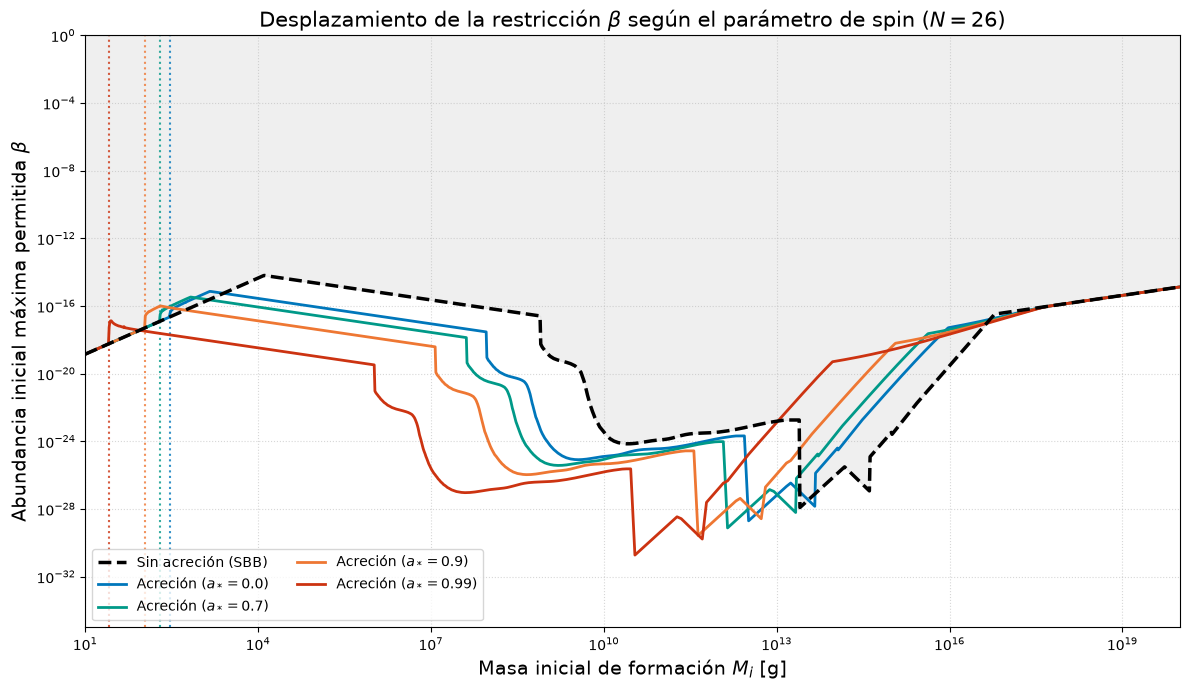

In [7]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star_list = [0.0, 0.7, 0.9, 0.99] 
    N_fin = 26
    
    # Colores diferenciados para cada spin
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE SPIN
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción y masas críticas para cada spin...")
    for idx, a_star in enumerate(a_star_list):
        print(f"   -> Procesando a_* = {a_star}...")
        limpiar_memoria()
        
        # 1. Cálculo de la masa crítica analítica para este a_star
        M_c = fn_comp.calcular_masa_critica_transicion(float(a_star))
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, float(a_star))
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente
        plt.plot(M_tot, betas_new_clean, 
                 label=rf"Acreción ($a_* = {a_star}$)", 
                 color=colores[idx], lw=2)
        
        # Línea vertical punteada con el mismo color para identificar su M_c
        plt.axvline(x=M_c, color=colores[idx], linestyle=':', lw=1.5, alpha=0.8)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según el parámetro de spin ($N={N_fin}$)', fontsize=15)
    
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=10, loc='lower left', ncol=2)
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()


1/4 - Generando arreglo cósmico de masas (desde PBHBeta modificado)...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo...
   -> Procesando  N = 25.50...
   -> Procesando  N = 25.80...
   -> Procesando  N = 26.00...
   -> Procesando  N = 26.50...
4/4 - Renderizando gráfica final...


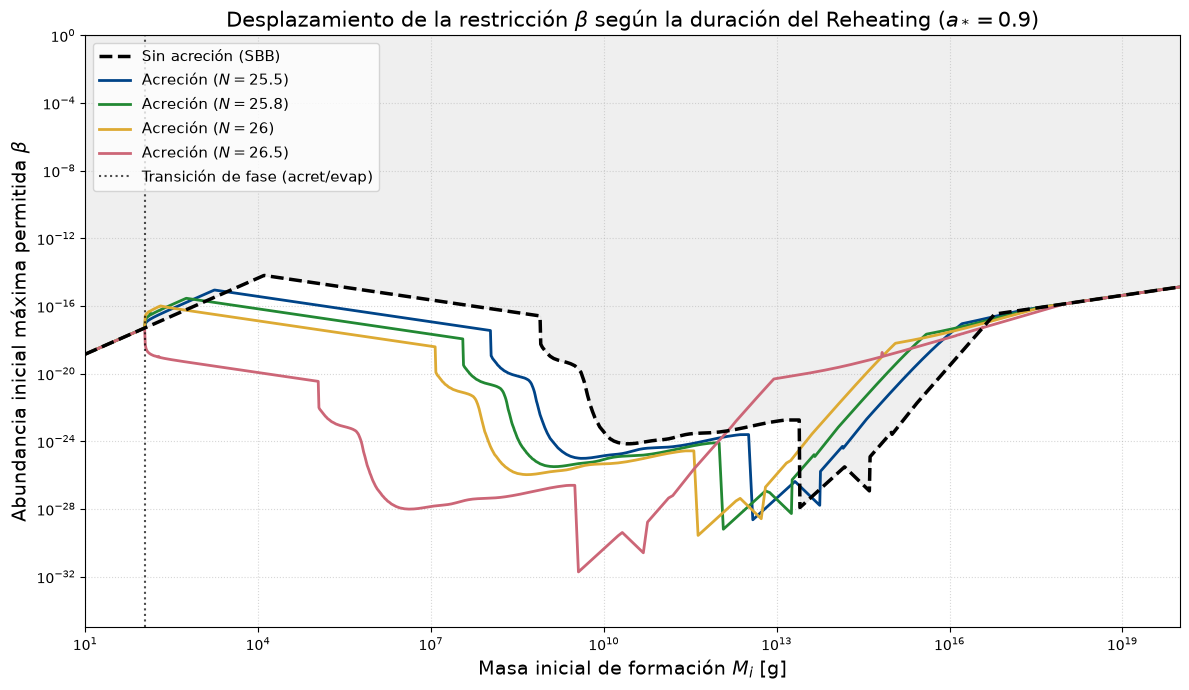

In [8]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_Tre_restricciones():
    print("1/4 - Generando arreglo cósmico de masas (desde PBHBeta modificado)...")
    # Llamamos a tu función original que YA tiene los 10,000 puntos configurados
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.9
    
    # Arreglo de N_efolds
    N_list = [25.5, 25.8,26,26.5]
    colores = ['#004488', '#228833', '#DDAA33', '#CC6677']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    M_c = fn_comp.calcular_masa_critica_transicion(float(a_star))
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo...")
    for idx, N in enumerate(N_list):
        N_fin = N
        print(f"   -> Procesando  N = {N_fin:.2f}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        # Obtener el arreglo final
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        
        # Graficación de la envolvente
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($N = {N_fin}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')
    plt.axvline(M_c, color = 'black', linestyle=':', alpha=0.7, label = 'Transición de fase (acret/evap)')
    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según la duración del Reheating ($a_*={a_star}$)', fontsize=15)
    
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_Tre_restricciones()

1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de Temperaturas...
   -> Procesando T_re = 1.00e+04 GeV (equivale a N_fin = 27.06)...
   -> Procesando T_re = 1.26e+04 GeV (equivale a N_fin = 26.82)...
   -> Procesando T_re = 1.58e+04 GeV (equivale a N_fin = 26.59)...
   -> Procesando T_re = 2.24e+04 GeV (equivale a N_fin = 26.25)...
   -> Procesando T_re = 2.51e+04 GeV (equivale a N_fin = 26.13)...
4/4 - Renderizando gráfica final...


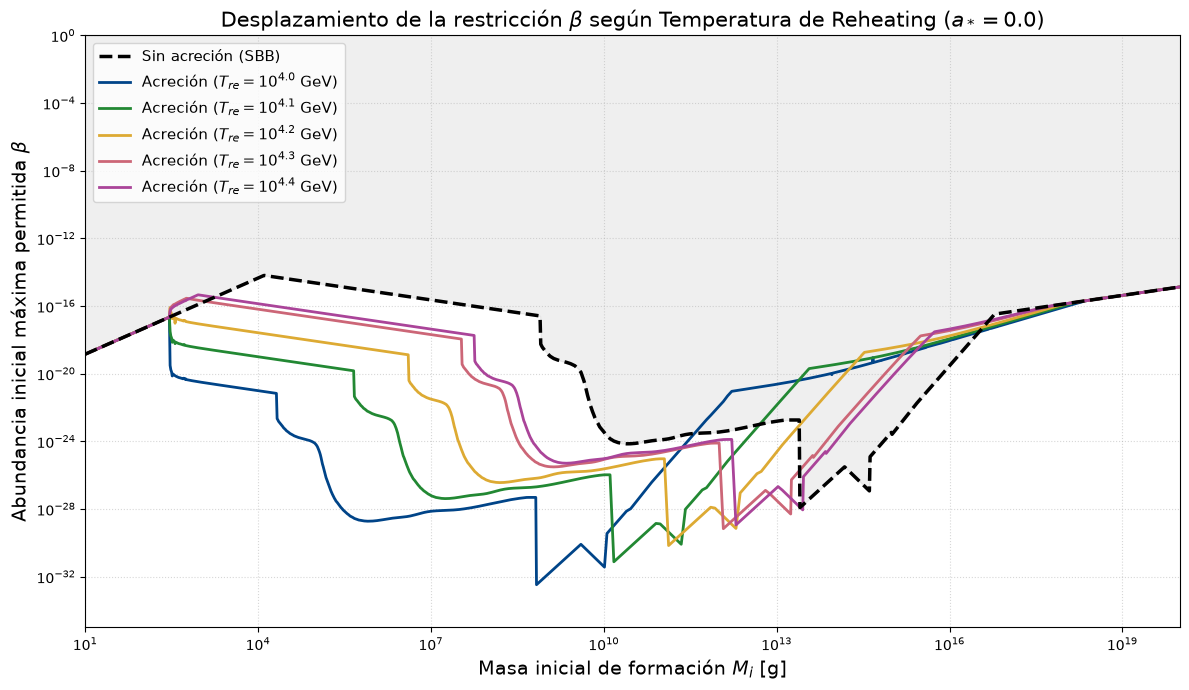

In [3]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def calcular_N_re(T_re_GeV, omega):
    """
    Despeja analíticamente el número de e-folds (N_re) a partir de la temperatura 
    de recalentamiento (T_re) en completa consistencia con las unidades de PBHBeta.
    """
    # Constantes en unidades físicas
    M_pl_GeV = 1.22089e19  # Masa de Planck no reducida (G^{-1/2}) usada en PBHBeta
    H_end_GeV = 4.44e13
    g_star = 106.75
    
    # 1. Conversión de TODO a unidades de Planck adimensionales
    T_re_pl = T_re_GeV / M_pl_GeV
    H_end_pl = H_end_GeV / M_pl_GeV
    
    # 2. Densidad al final de inflación (Idéntica a PBHBeta)
    rho_end_pl = (3.0 * H_end_pl**2.0) / (8.0 * np.pi)
    
    # 3. Términos de la ecuación 2.46 del artículo
    termino_constante = (30.0 / (np.pi**2 * g_star))**0.25
    rho_cuarto_pl = rho_end_pl**0.25
    
    # 4. Despeje de N_re (ahora el argumento es >> 1, dando N_re positivo)
    argumento_ln = termino_constante * (rho_cuarto_pl / T_re_pl)
    N_re = (4.0 / (3.0 * (1.0 + omega))) * np.log(argumento_ln)
    
    return N_re

def comparar_Tre_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.0
    
    # Rango de temperaturas (GeV)
    T_re_list = [10**4.0, 10**4.1, 10**4.2, 10**4.35, 10**4.4]
    
    # Paleta de colores secuencial para simular un mapa de calor similar a la gráfica original
    colores = ['#004488', '#228833', '#DDAA33', '#CC6677', '#AA4499']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE TEMPERATURA
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de Temperaturas...")
    for idx, T_re in enumerate(T_re_list):
        # Mapeo físico de T_re a N_fin
        N_fin = calcular_N_re(T_re, omega)
        
        print(f"   -> Procesando T_re = {T_re:.2e} GeV (equivale a N_fin = {N_fin:.2f})...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Exponente en base 10 para una leyenda más limpia
        log_Tre = np.log10(T_re)
        
        # Graficación de la envolvente con acreción
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($T_{{re}} = 10^{{{log_Tre:.1f}}}$ GeV)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según Temperatura de Reheating ($a_*={a_star}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_Tre_restricciones()

In [9]:
#Esto no es una contradicción? es decir, Mientras mayor N, menor T_RH, entonces, los PBHs deben ser más 
#masivos, por ello, los constraints en PBHs de masas mayores deben permitir una mayor abundancia.

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


/tmp/ipykernel_20698/2562497999.py:109: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


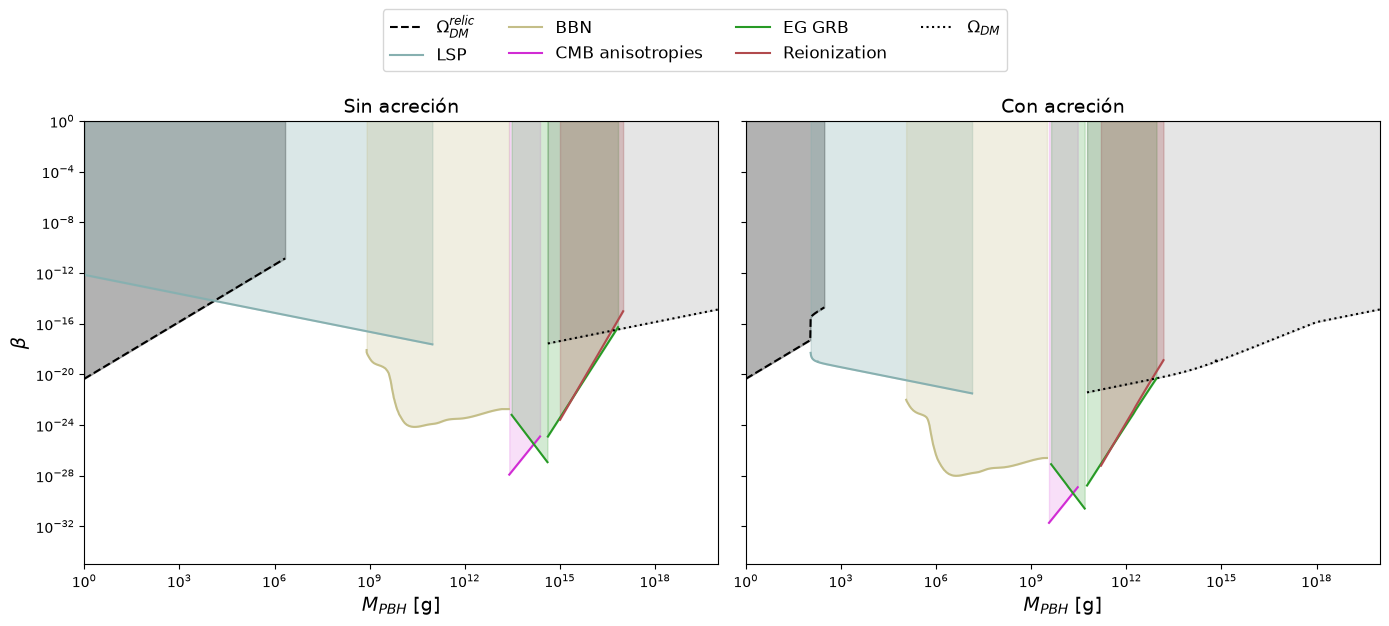

In [12]:

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Reheating dominado por materia
    N = 26.50
    a = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N, a)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title(f"Con acreción ($N = {N_fin}, a_* = {a_star}$)", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

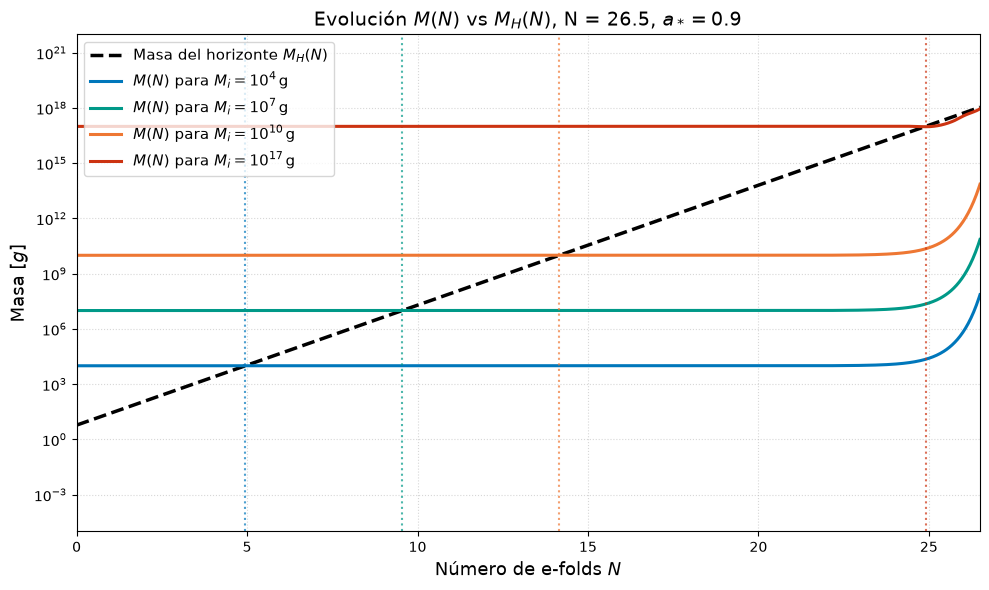

In [11]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from diffrax import diffeqsolve, ODETerm, Tsit5, PIDController, SaveAt
import matplotlib.pyplot as plt

@eqx.filter_jit
def trayectoria_pbh_vs_horizonte(Mi_val_g, N_fin, a_star, N_puntos=1000):
    M_pl_GeV = 1.22089e19
    M_pl_g = 2.17645e-5
    H_end_GeV = 4.44e13 
    
    M_i_pl = Mi_val_g / M_pl_g
    H_end_pl = H_end_GeV / M_pl_GeV

    n = 100.0 
    mu_pl = n * H_end_pl 
    rho_end_inf_pl = (3.0 * H_end_pl**2.0) / (8.0 * jnp.pi)
    phi_ini_pl = jnp.sqrt(2.0 * rho_end_inf_pl / (mu_pl**2.0 + 9.0 * H_end_pl**2.0 / 4.0))

    M_end_pl = 1.0 / H_end_pl
    N_ini = (2.0 / 3.0) * jnp.log(jnp.maximum(M_i_pl / M_end_pl, 1.0))
    a_star_safe = jnp.clip(a_star, 0.0, 0.999)

    # Factores de Kerr para la evaporación
    raiz_espin = jnp.sqrt(jnp.maximum(1.0 - a_star_safe**2.0, 1e-12))
    factor_T_kerr = (2.0 * raiz_espin) / (1.0 + raiz_espin)
    factor_Area_kerr = 0.5 * (1.0 + raiz_espin)
    factor_evap_kerr = (factor_T_kerr**4.0) * factor_Area_kerr

    def Hubble(N):
        return H_end_pl * jnp.exp(-3.0 * N / 2.0)

    def rho_inf_field_env(N):
        return 0.5 * (phi_ini_pl * mu_pl)**2 * jnp.exp(-3.0 * N)

    def C4(M_val, rho_inf_val):
        w = 0.0 
        a = a_star_safe * M_val 
        r_plus = M_val + jnp.sqrt(jnp.maximum(M_val**2.0 - a**2.0, 1e-12))
        u_c = M_val / (2.0 * r_plus)
        rho_h = 3.0 * M_val / (4.0 * jnp.pi * r_plus**3.0)
        return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

    def vector_field_log(N, u, args):
        # Si aún no cruza el horizonte, la masa permanece estática
        du_dN_cero = 0.0

        u_safe = jnp.maximum(u, -1.0)
        M_actual = jnp.exp(u_safe)
        M_reg = jnp.sqrt(M_actual**2.0 + 1.0)
        
        rho_val = rho_inf_field_env(N) 
        H_val   = Hubble(N)
        
        # 1. Dinámica de Acreción
        C_4_val = C4(M_reg, rho_val)
        a = a_star_safe * M_reg 
        r_plus = M_reg + jnp.sqrt(jnp.maximum(M_reg**2.0 - a**2.0, 1e-12))
        
        f_acc_base = 1e-18
        supresion = M_reg * mu_pl
        f_acc = f_acc_base * supresion
        dM_dN_acrecion = f_acc * 4.0 * jnp.pi * C_4_val * r_plus**2.0 * (rho_val / H_val)
        M_H_actual = 1.0 / H_val
        factor_causal = jnp.clip(1.0 - (M_reg / M_H_actual), 0.0, 1.0)
        dM_dN_acrecion = dM_dN_acrecion * factor_causal
        # 2. Dinámica de Evaporación
        dM_dt_evap_pl = - (1.0 / (3.0 * (M_actual**2.0 + 1.0))) * factor_evap_kerr
        dM_dN_evap_real = dM_dt_evap_pl / H_val
        
        # 3. Transición logarítmica suave
        factor_apagado = 0.5 * (1.0 + jnp.tanh(u * 3.0))
        dM_dN_total = (dM_dN_acrecion + dM_dN_evap_real) * factor_apagado
        
        # 4. Transformación du/dN y saturación
        du_dN_raw = dM_dN_total / M_actual
        du_dN_sat = jnp.clip(du_dN_raw, -50.0, 50.0)
        du_dN_val = jnp.where(u < 0.0, 0.0, du_dN_sat)
        
        # Activar la derivada únicamente cuando N >= N_ini
        return jnp.where(N < N_ini, du_dN_cero, du_dN_val)

    # Malla temporal completa contenida estrictamente en [t0, t1]
    ts_eval = jnp.linspace(0.0, N_fin, N_puntos)
    saveat = SaveAt(ts=ts_eval)
    
    term = ODETerm(vector_field_log)
    solver = Tsit5()
    stepsize_controller = PIDController(rtol=1e-4, atol=1e-4, pcoeff=0.2, icoeff=0.7)

    u_0 = jnp.log(jnp.maximum(M_i_pl, 1.0))
    dt0_val = (N_fin / N_puntos) * 0.1
    
    sol = diffeqsolve(
        term, 
        solver, 
        t0=0.0, 
        t1=N_fin, 
        dt0=dt0_val, 
        y0=u_0, 
        stepsize_controller=stepsize_controller, 
        saveat=saveat, 
        max_steps=20000,
        throw=False
    )
    
    u_arr = jnp.maximum(sol.ys, 0.0)
    M_pbh_pl = jnp.exp(u_arr)
    M_pbh_g = M_pbh_pl * M_pl_g

    # Masa del horizonte M_H(N) en gramos
    M_H_pl = 1.0 / Hubble(ts_eval)
    M_H_g = M_H_pl * M_pl_g

    return ts_eval, M_pbh_g, M_H_g, N_ini


def plot_horizonte_vs_pbh():
    N_fin = 26.5
    a_star = 0.9
    masas_prueba = [1e4, 1e7, 1e10, 1e17]  # Masas en gramos
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']

    plt.figure(figsize=(10, 6))

    # Evolución del horizonte de Hubble
    N_grid, _, M_H_g, _ = trayectoria_pbh_vs_horizonte(masas_prueba[0], N_fin, a_star)
    plt.plot(N_grid, M_H_g, color='black', linestyle='--', lw=2.5, label=r'Masa del horizonte $M_H(N)$')

    for idx, M_i in enumerate(masas_prueba):
        _, M_pbh_g, _, N_ini = trayectoria_pbh_vs_horizonte(M_i, N_fin, a_star)
        
        plt.plot(N_grid, M_pbh_g, color=colores[idx], lw=2.2, 
                 label=rf'$M(N)$ para $M_i = 10^{{{int(np.log10(M_i))}}}\,$g')
        
        plt.axvline(x=float(N_ini), color=colores[idx], linestyle=':', alpha=0.7)

    plt.yscale('log')
    plt.xlabel(r'Número de e-folds $N$', fontsize=13)
    plt.ylabel(r'Masa $[g]$', fontsize=13)
    plt.title(rf'Evolución $M(N)$ vs $M_H(N)$, N = {N_fin}, $a_* = {a_star}$' ,fontsize=14)
    plt.xlim(0, N_fin)
    plt.ylim(1e-5, 1e22)
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.legend(fontsize=11, loc='upper left')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_horizonte_vs_pbh()